In [3]:
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
from einops import rearrange
import torch
from torch.utils.data import Dataset
from tqdm import tqdm
import glob
import os

In [2]:
data_multi = xr.open_dataset('data/paris/paris-before-s2.nc')
data_hyper = xr.open_dataset('data/paris/paris-before-prs.nc')

In [3]:
#data_multi["cw"].data # /!\ il n'y a pas la band 10 = 1375nm, d'où shape (12,) au lieu de (13,)

wavelength_hyper = data_hyper["cw"].data
wavelength_hyper = np.round(wavelength_hyper).astype(int) # on arrondit les longueurs d'ondes à l'entier le plus proche pour faciliter la comparaison avec les bandes multispectrales

In [4]:
img_multi = data_multi["sr"].to_numpy()
img_multi = np.clip(img_multi, 0.0, 1.0)
img_hyper = data_hyper["sr"].to_numpy()

In [5]:
df = pd.read_excel('data/sr_s2b.xlsx')
df = df.drop(columns=['S2B_SR_AV_B10']) #on supprime la colonne S2B_SR_AV_B10 pour match le dataset multispectral
print("shape df:", df.shape)

shape df: (2301, 13)


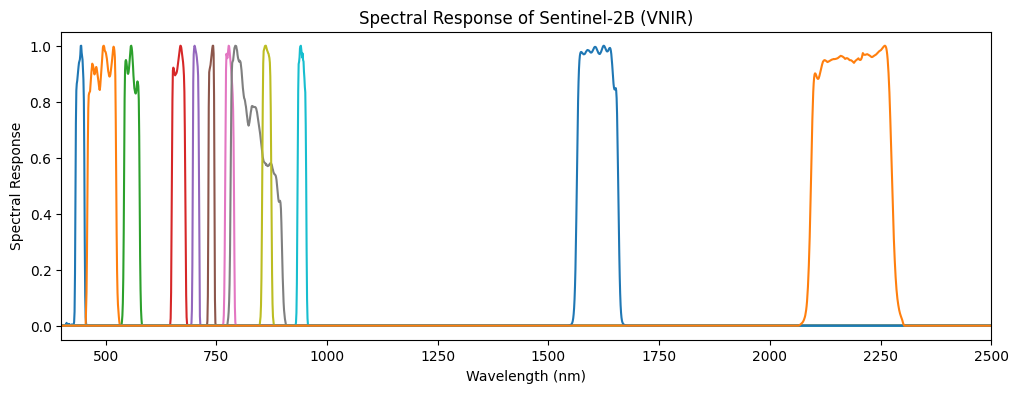

In [6]:
plt.figure(figsize=(12, 4))
for i in range(1, df.shape[1]):  # Skip the first column (wavelength)
    plt.plot(df['SR_WL'], df[df.columns[i]], label=df.columns[i])
plt.xlabel('Wavelength (nm)')
plt.ylabel('Spectral Response')
plt.title('Spectral Response of Sentinel-2B (VNIR)')
plt.xlim(400, 2500)
plt.show()

In [7]:
# on garde seulement les lignes du df dont les longueurs d'ondes sont présentes dans le dataset hyperspectral
df_hyper = df[df[df.columns[0]].isin(wavelength_hyper)]
df_hyper = df_hyper.reset_index(drop=True)
srf_matrix = df_hyper.iloc[:, 1:].to_numpy()
srf_matrix_norm = srf_matrix / np.sum(srf_matrix, axis=0)

print("shape srf_matrix:", srf_matrix.shape) # Shape attendue : (230, 12)
#np.save('data/srf_matrix_norm_s2b.npy', srf_matrix_norm)

shape srf_matrix: (230, 12)


In [8]:
def from_hyper_to_multi(img_hyper, srf_matrix_norm):
    h, w, c = img_hyper.shape
    hyper_2d = img_hyper.reshape(h * w, c)              
    multi_2d = np.dot(hyper_2d, srf_matrix_norm)         
    image_multispec = multi_2d.reshape(h, w, srf_matrix_norm.shape[1])
    return image_multispec

In [9]:
img_multi_simulated = from_hyper_to_multi(img_hyper, srf_matrix_norm)

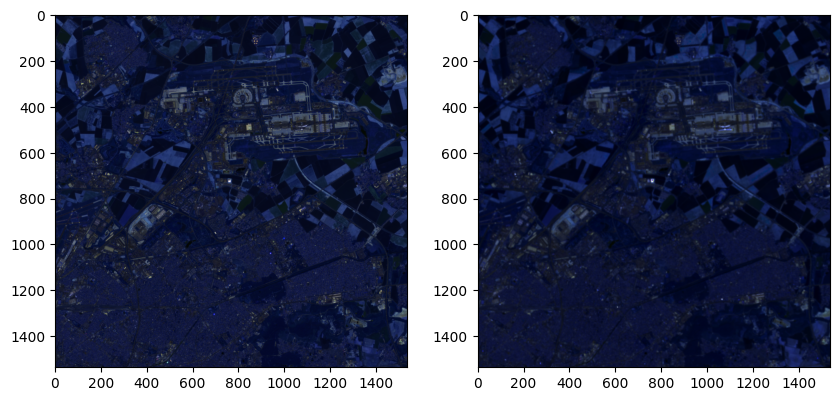

In [10]:
channels_multi_mask = [1, 2, 10] # Example channel indices for multispectral data to plot

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img_multi[:,:,channels_multi_mask], cmap='gray')
axes[1].imshow(img_multi_simulated[:,:,channels_multi_mask], cmap='gray')

In [11]:
#norm error
error = np.linalg.norm(img_multi - img_multi_simulated) / np.linalg.norm(img_multi)
print("Normalized error between original and simulated multispectral images:", error)

Normalized error between original and simulated multispectral images: 0.20476488551653066


In [4]:
from src.utils_dataset import SpectralDataset

In [20]:
dataset = SpectralDataset()
dataloader = torch.utils.data.DataLoader(dataset, batch_size=8, shuffle=True)

Loaded 144 patches from 4 files.


In [21]:
for X_batch, y_batch in dataloader:
    print("Shape X_batch:", X_batch.shape)  # Expected: (batch_size, C_multi, patch_size, patch_size)
    print("Shape y_batch:", y_batch.shape)  # Expected: (batch_size, C_hyper, patch_size, patch_size)
    break

Shape X_batch: torch.Size([8, 12, 256, 256])
Shape y_batch: torch.Size([8, 230, 256, 256])


Text(0.5, 1.0, 'Hyperspectral Patch')

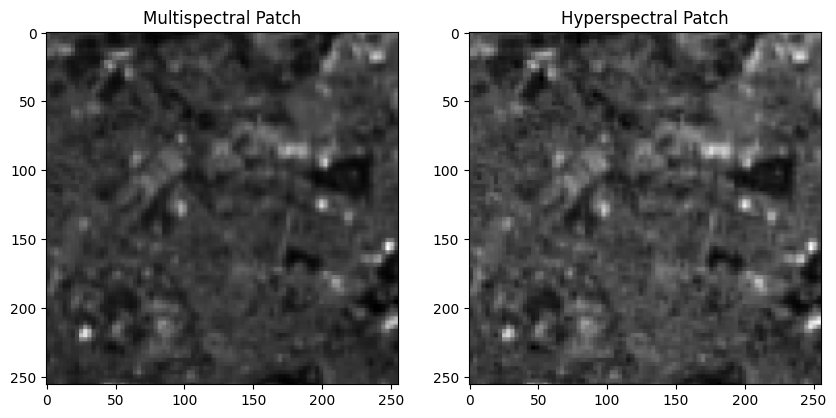

In [22]:
idx_sample = np.random.randint(0, X_batch.shape[0])
X_sample = X_batch[idx_sample].permute(1, 2, 0).numpy() 
y_sample = y_batch[idx_sample].permute(1, 2, 0).numpy()
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(X_sample[:,:,0], cmap='gray')
plt.title('Multispectral Patch')
plt.subplot(1, 2, 2)
plt.imshow(y_sample[:, :, 0], cmap='gray')
plt.title('Hyperspectral Patch')

In [23]:
from src.models import GradualExpansionUNet

In [36]:
model = GradualExpansionUNet(interpolation_mode="ConvTranspose2d")
model.load_state_dict(torch.load('saves/model3/best_model.pth', map_location=torch.device('cpu')))
model.eval();

In [37]:
y_batch_pred = model(X_batch)

In [38]:
#norm error
error = torch.linalg.norm(y_batch_pred - y_batch) / torch.linalg.norm(y_batch)
print("Normalized error between original and simulated multispectral images:", error.item())

Normalized error between original and simulated multispectral images: 0.11091096699237823


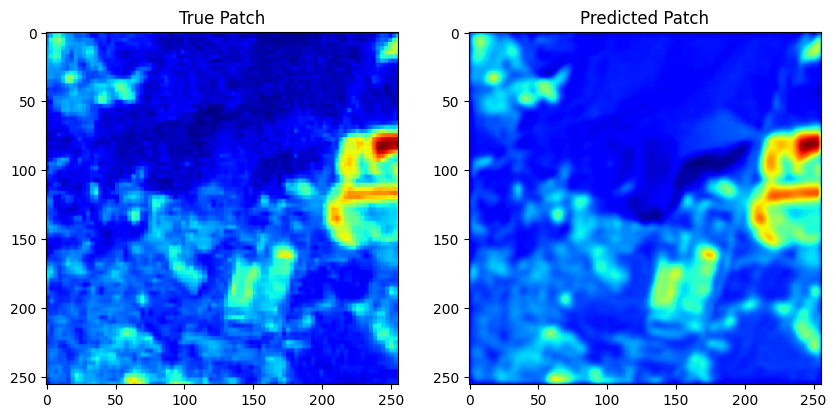

In [39]:
idx_sample = np.random.randint(0, X_batch.shape[0])
y_pred_sample = y_batch_pred[idx_sample].permute(1, 2, 0).detach().numpy() 
y_sample = y_batch[idx_sample].permute(1, 2, 0).detach().numpy()


for i in range(1):
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(y_sample[:,:,i], cmap='jet')
    plt.title('True Patch')
    plt.subplot(1, 2, 2)
    plt.imshow(y_pred_sample[:, :, i], cmap='jet')
    plt.title('Predicted Patch')

Text(0.5, 1.0, 'Ground Truth')

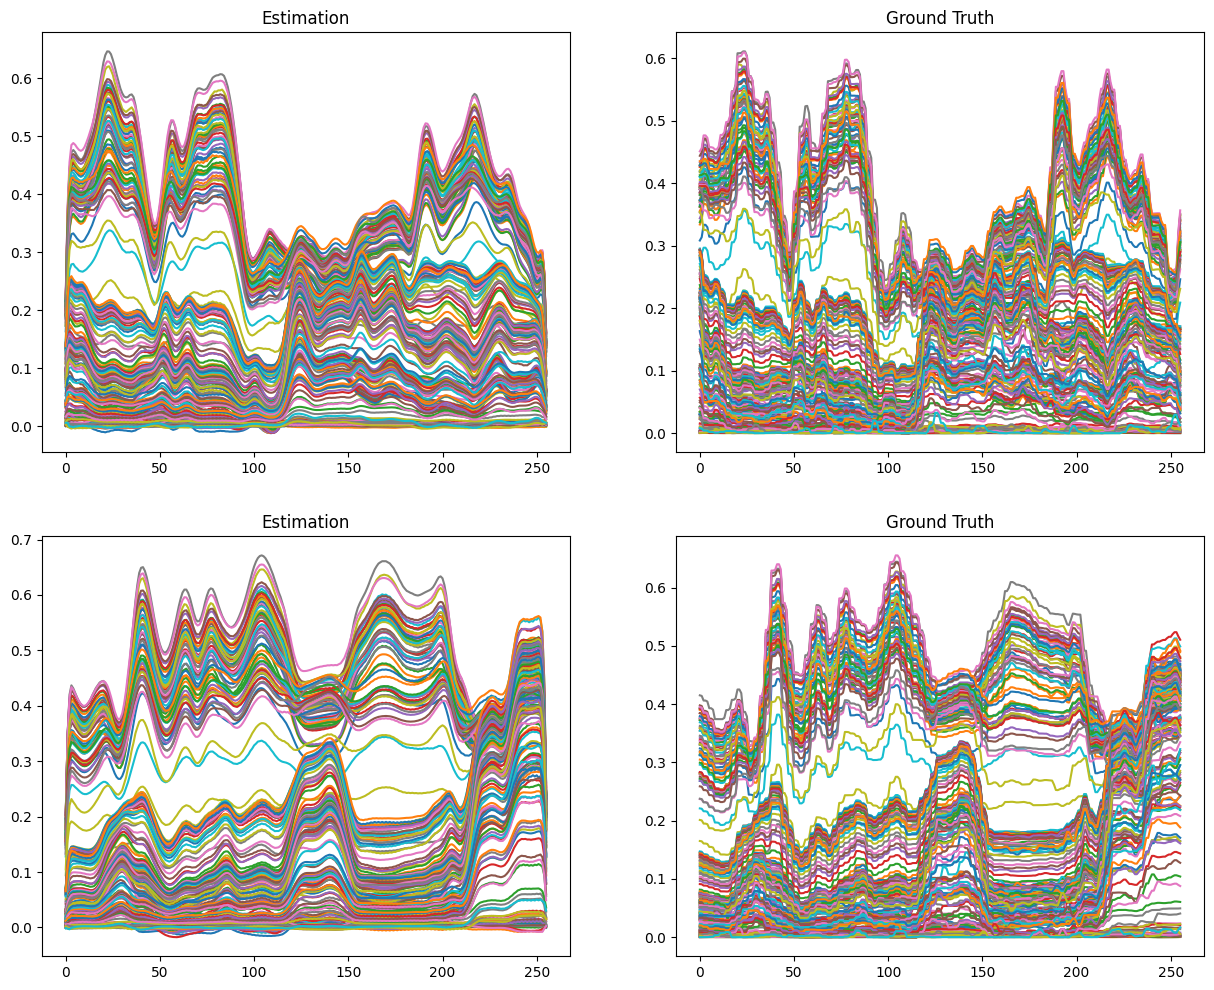

In [40]:
idx_rand = np.random.randint(0, y_sample.shape[1])

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

axes[0, 0].plot(y_pred_sample[:, idx_rand, :])
axes[0, 0].set_title('Estimation')
axes[0, 1].plot(y_sample[:, idx_rand, :])
axes[0, 1].set_title('Ground Truth')

axes[1, 0].plot(y_pred_sample[idx_rand, :, :])
axes[1, 0].set_title('Estimation')
axes[1, 1].plot(y_sample[idx_rand, :, :])
axes[1, 1].set_title('Ground Truth')

In [41]:
def evalSR(HSI0,HSI_est):
    # HSI0: ground-truth HSI (cube)
    # HSI_est: estimated HSI (cube)
    HSI0 = HSI0.reshape(HSI0.shape[0],HSI0.shape[1]*HSI0.shape[2])
    HSI_est = HSI_est.reshape(HSI_est.shape[0],HSI_est.shape[1]*HSI_est.shape[2])
    
    metriqueTab = np.zeros(HSI0.shape[1])
    for ii in range(HSI0.shape[1]):
        metriqueTab[ii] = np.sum(HSI0[:,ii]*HSI_est[:,ii])/(np.linalg.norm(HSI0[:,ii])*np.linalg.norm(HSI_est[:,ii])+1e-10) # on ajoute une petite valeur pour éviter la division par zéro
        
    return np.mean(np.abs(metriqueTab))

In [42]:
print('SAD interpolation bilineaire en dB: ',-10*np.log10(np.abs(1-(evalSR(y_sample, y_pred_sample)))))

SAD interpolation bilineaire en dB:  14.24683182154303
